# Modeling


**TODO**
- **done** different models for rec, resl and rest (up to now only resl)
- **done** try bayesian optimization with xgboost/ fix hyperopt: what's the issue?
- **done** include categorical variable "veg_class"
- **done** add models for kndvi anomaly?
- **done** check for overfitting: for each model, print training vs test R2 -> maybe have to work with gamma
- **done** SHAP for resistance and recovery
- use different optimization function: where difference of r2 on test and validation set are minimal


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# ML
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe 
import shap

## Prepare data for model

In [118]:
# Load prepared data
df = pd.read_csv('data/output/10_14.csv')

In [119]:
df

,event_label,veg_class,n_days,t2m,t2mmin,t2mmax,prec,soil_moist,evap,evap_pot,...,vpre,vdist,vpost,resilience,resistance,recovery_dep,recovery,n_days_vdist,kndvi_anomaly_strength,kndvi_anomaly_strength_average
0,83007,1.0,9.439828,1.162104,-2.967387,5.105245,0.949040,0.160487,0.619684,0.623335,...,0.120894,0.209158,0.126759,1.048513,1.730091,-1.812490,0.606045,70.0,-0.033406,-0.003712
1,83007,5.0,17.539571,2.715765,-1.923518,7.213997,1.098168,0.186558,0.794822,0.825940,...,0.153942,0.265022,0.155799,1.012060,1.721568,-1.830791,0.587871,70.0,-0.071349,-0.007928
2,83007,7.0,6.909091,8.442572,2.001552,15.046614,0.510140,0.141689,0.385934,1.074128,...,0.044753,0.050352,0.044363,0.991278,1.125092,-1.131081,0.881064,46.0,-0.055976,-0.006220
3,83007,10.0,14.817383,6.538987,0.334209,12.659201,0.580634,0.173629,0.413866,1.022274,...,0.044536,0.038875,0.047521,1.067030,0.872893,-0.864247,1.222406,70.0,-0.043685,-0.004854
4,83007,12.0,18.372679,5.159230,-0.109135,10.355434,1.037939,0.234533,0.783485,0.961051,...,0.121763,0.148193,0.122474,1.005834,1.217060,-1.242780,0.826446,70.0,-0.152751,-0.016972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,103567,12.0,6.000000,27.372594,24.025354,31.970584,5.551070,0.419721,2.872893,3.743174,...,0.263038,0.082500,0.296078,1.125607,0.313641,-0.100063,3.588841,6.0,-0.136300,-0.045433
608,81632,2.0,18.000000,17.339939,11.600028,23.768463,5.917609,0.445089,2.865942,2.874007,...,0.541131,0.501824,0.536009,0.990535,0.927362,-0.893177,1.068121,19.0,-0.064239,-0.021413
609,79098,7.0,12.000000,-2.163839,-5.869774,1.569444,0.930501,0.243993,0.451534,0.456318,...,0.074522,0.231508,0.075315,1.010635,3.106557,-3.262750,0.325323,23.0,0.000912,0.000304
610,121988,2.0,8.000000,25.508486,23.221017,28.529593,7.816896,0.105242,4.273697,4.762981,...,0.431877,0.352132,0.444803,1.029930,0.815352,-0.722681,1.263172,3.0,-0.071151,-0.023717


In [4]:
# One hot encoding of vegetation class
dummies = pd.get_dummies(df['veg_class'])
df = df.join(dummies) # Add to df

In [5]:
# Get number of class occurrences
print(df['veg_class'].value_counts())

veg_class
2.0     94
10.0    74
7.0     61
12.0    56
9.0     49
8.0     48
5.0     46
14.0    26
19.0    25
1.0     22
4.0     22
13.0    21
16.0    21
18.0    17
15.0    16
6.0     10
11.0     2
3.0      2
Name: count, dtype: int64


uneven class distributions -> stratified train-test-split required

In [229]:
# Split into features and targets
X = df.drop(['other_events', 'vpre', 'vdist', 'vpost', 'resilience', 'resistance',
       'recovery', 'n_days_vdist', 'kndvi_anomaly_strength',
       'kndvi_anomaly_strength_average', 'veg_class', 'event_label', 'recovery_dep'], axis=1)

y_resl = df['resilience']
y_rest = df['resistance']
y_rec = df['recovery']
y_anom = df['kndvi_anomaly_strength_average']

# Split into train and test set
X_train_resl, X_test_resl, y_train_resl, y_test_resl = train_test_split(X, y_resl, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resilience
X_train_rest, X_test_rest, y_train_rest, y_test_rest = train_test_split(X, y_rest, test_size=0.2, random_state=123, stratify=df['veg_class']) # Resistance
X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y_rec, test_size=0.2, random_state=123, stratify=df['veg_class']) # Recovery
X_train_anom, X_test_anom, y_train_anom, y_test_anom = train_test_split(X, y_anom, test_size=0.2, random_state=123, stratify=df['veg_class']) # Anomaly strength


**One out of ten rule:** I need at least 230 observations without vegetation class and 400 with vegetation classes one-hot encoded.
Maybe use vegetation class only for stratified train-test-split.
- resistance and recovery are not uniformly distributed -> number of samples should be sufficient for these events
- if anyting, dimensionality reduction could help to reduce the number of predictors

## Extreme Gradient Boosting

In [230]:
'''# Define the hyperparameter space
space = {
    # Learning rate
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.2)),

    # min_split_loss
    'gamma': hp.uniform('gamma', 0, 10),

    # Tree structure
    'max_depth': hp.uniform('max_depth', 2, 10),
    'min_child_weight': hp.uniform('min_child_weight', 2, 10),

    # Sampling parameters (linear fractions)
    'subsample': hp.uniform('subsample', 0.5, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),

    # L1 regularization (alpha)
    'alpha': hp.uniform('alpha', 0, 100)
}'''

"# Define the hyperparameter space\nspace = {\n    # Learning rate\n    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.2)),\n\n    # min_split_loss\n    'gamma': hp.uniform('gamma', 0, 10),\n\n    # Tree structure\n    'max_depth': hp.uniform('max_depth', 2, 10),\n    'min_child_weight': hp.uniform('min_child_weight', 2, 10),\n\n    # Sampling parameters (linear fractions)\n    'subsample': hp.uniform('subsample', 0.5, 1),\n    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1),\n\n    # L1 regularization (alpha)\n    'alpha': hp.uniform('alpha', 0, 100)\n}"

In [314]:
# Example revised hyperparameter bounds
space = {
    'eta': hp.loguniform('eta', np.log(0.01), np.log(0.1)),        
    'gamma': hp.uniform('gamma', 0, 5),
    'max_depth': hp.quniform('max_depth', 2, 6, 1),                
    'min_child_weight': hp.loguniform('min_child_weight', np.log(1), np.log(20)),
    'subsample': hp.uniform('subsample', 0.6, 1),                  
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1),    
    'alpha': hp.loguniform('alpha', np.log(0.1), np.log(10)),     
    'reg_lambda': hp.loguniform('reg_lambda', np.log(0.1), np.log(10)) 
}


### Resilience

In [339]:
# Define objevtice function
def objective_cv_resl(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=41,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha'],
    reg_lambda=space['reg_lambda'],  
    n_estimators = 1000
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_resl, y_train_resl, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_resl = fmin(
    fn = objective_cv_resl,
    space=space,
    algo = tpe.suggest,
    max_evals = 300,
    trials = trials,
    rstate = np.random.default_rng(41)
)


100%|██████████| 300/300 [07:04<00:00,  1.42s/trial, best loss: 0.0074644980477783255]


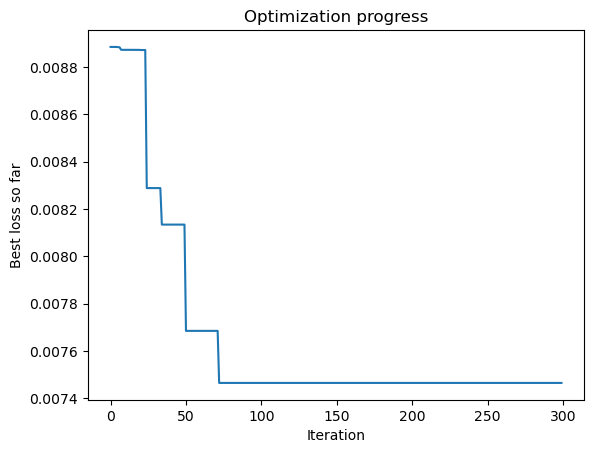

In [340]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

In [341]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_resl = xgb.XGBRegressor(
    eta = best_hyperparams_resl['eta'],
    gamma = best_hyperparams_resl['gamma'],
    max_depth = int(best_hyperparams_resl['max_depth']),
    min_child_weight = int(best_hyperparams_resl['min_child_weight']),
    subsample = best_hyperparams_resl['subsample'],
    colsample_bytree = best_hyperparams_resl['colsample_bytree'],
    alpha = best_hyperparams_resl['alpha'],
    reg_lambda = best_hyperparams_resl['reg_lambda']
)


# Fit the model to the training data
xgb_resl.fit(X_train_resl, y_train_resl)

XGBRegressor(alpha=np.float64(0.22173377383754572), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.8046949741051628), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.03295289183205311), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.00016929543343517303), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [342]:
# Predict on training data
y_pred_resl_train = xgb_resl.predict(X_train_resl)

# Predict on test data
y_pred_resl_test = xgb_resl.predict(X_test_resl)

# Compute R² on both
r2_train = r2_score(y_train_resl, y_pred_resl_train)
r2_test = r2_score(y_test_resl, y_pred_resl_test)

print(r2_test)
print(r2_train)

0.10261024551452724
0.7300032245342198


### Resistance

In [343]:
# Define objevtice function
def objective_cv_rest(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha'],
    n_estimators = 1000
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rest, y_train_rest, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rest = fmin(
    fn = objective_cv_rest,
    space=space,
    algo = tpe.suggest,
    max_evals = 300,
    trials = trials,
    rstate = np.random.default_rng(123)
)


  0%|          | 0/300 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 300/300 [08:39<00:00,  1.73s/trial, best loss: 0.09023336065759469]


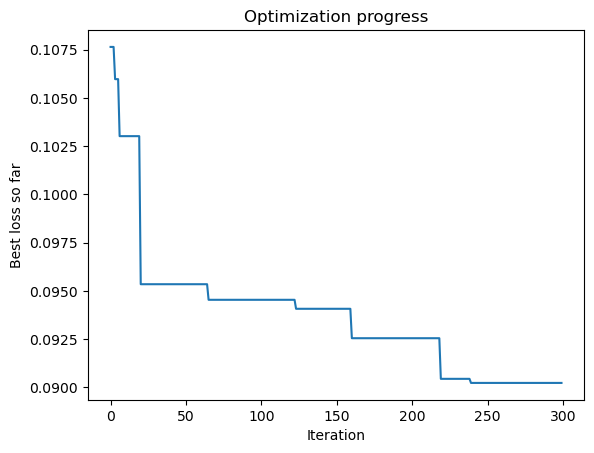

In [344]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

In [345]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rest = xgb.XGBRegressor(
    eta = best_hyperparams_rest['eta'],
    gamma = best_hyperparams_rest['gamma'],
    max_depth = int(best_hyperparams_rest['max_depth']),
    min_child_weight = int(best_hyperparams_rest['min_child_weight']),
    subsample = best_hyperparams_rest['subsample'],
    colsample_bytree = best_hyperparams_rest['colsample_bytree'],
    alpha = best_hyperparams_rest['alpha']    
)


# Fit the model to the training data
xgb_rest.fit(X_train_rest, y_train_rest)

XGBRegressor(alpha=np.float64(0.18356409815310343), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.6841092566075835), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.0198568979775374), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.0023656288947945547), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [346]:
# Predict on training data
y_pred_rest_train = xgb_rest.predict(X_train_rest)

# Predict on test data
y_pred_rest_test = xgb_rest.predict(X_test_rest)

# Compute R² on both
r2_train = r2_score(y_train_rest, y_pred_rest_train)
r2_test = r2_score(y_test_rest, y_pred_rest_test)

print(r2_train)
print(r2_test)

0.9383894342915418
0.8556360120120796


### Recovery

In [331]:
# Define objevtice function
def objective_cv_rec(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha'],
    n_estimators = 1000
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_rec, y_train_rec, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_rec = fmin(
    fn = objective_cv_rec,
    space=space,
    algo = tpe.suggest,
    max_evals = 700,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 700/700 [27:09<00:00,  2.33s/trial, best loss: 0.18974675890137807]


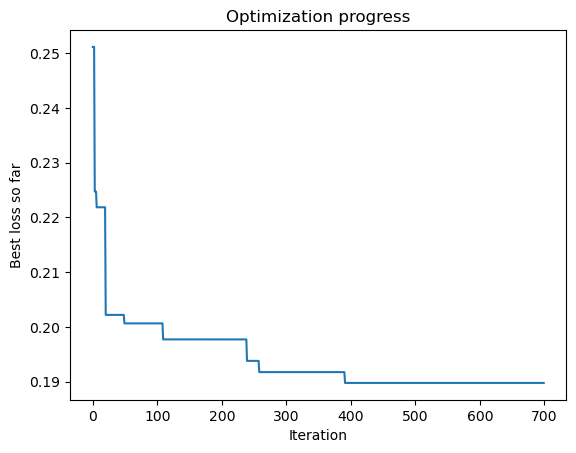

In [332]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

In [333]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_rec = xgb.XGBRegressor(
    eta = best_hyperparams_rec['eta'],
    gamma = best_hyperparams_rec['gamma'],
    max_depth = int(best_hyperparams_rec['max_depth']),
    min_child_weight = int(best_hyperparams_rec['min_child_weight']),
    subsample = best_hyperparams_rec['subsample'],
    colsample_bytree = best_hyperparams_rec['colsample_bytree'],
    alpha = best_hyperparams_rec['alpha']    
)


# Fit the model to the training data
xgb_rec.fit(X_train_rec, y_train_rec)

XGBRegressor(alpha=np.float64(0.5500467423911684), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.7571510067206192), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.029524104377736927), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.0032390913019849786), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=2, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [334]:
# Predict on training data
y_pred_rec_train = xgb_rec.predict(X_train_rec)

# Predict on test data
y_pred_rec_test = xgb_rec.predict(X_test_rec)

# Compute R² on both
r2_train = r2_score(y_train_rec, y_pred_rec_train)
r2_test = r2_score(y_test_rec, y_pred_rec_test)

print(r2_train)
print(r2_test)

0.8762603873485232
0.7304613423532866


#### kNDVI anomaly strength

In [335]:
# Define objevtice function
def objective_cv_anom(space):
    model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=123,
    eta=space['eta'],
    gamma=space['gamma'],
    max_depth=int(space['max_depth']),
    min_child_weight=int(space['min_child_weight']),
    subsample=space['subsample'],
    colsample_bytree=space['colsample_bytree'],
    alpha=space['alpha'],
    n_estimators=1000
)

    # Perform cross-validation
    cv_results = cross_val_score(model, X_train_anom, y_train_anom, cv=5, scoring='neg_mean_squared_error')

    # Compute the mean of the negative MSE scores
    mse = -cv_results.mean()

    return {'loss': mse, 'status': STATUS_OK}

# Store results
trials = Trials()

# Run optimization
best_hyperparams_anom = fmin(
    fn = objective_cv_anom,
    space=space,
    algo = tpe.suggest,
    max_evals = 600,
    trials = trials,
    rstate = np.random.default_rng(123)
)


100%|██████████| 600/600 [13:01<00:00,  1.30s/trial, best loss: 0.000564086965701725] 


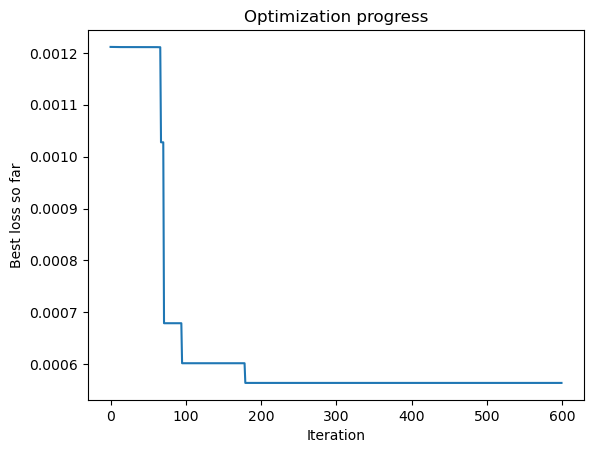

In [336]:
# Track best so far loss
losses = np.array([t['result']['loss'] for t in trials.trials])
best_so_far = np.minimum.accumulate(losses)

plt.plot(best_so_far)
plt.xlabel('Iteration')
plt.ylabel('Best loss so far')
plt.title('Optimization progress')
plt.show()

In [337]:
# Initiate model with the best hyperparameters from Bayesian optimization
xgb_anom = xgb.XGBRegressor(
    eta = best_hyperparams_anom['eta'],
    gamma = best_hyperparams_anom['gamma'],
    max_depth = int(best_hyperparams_anom['max_depth']),
    min_child_weight = int(best_hyperparams_anom['min_child_weight']),
    subsample = best_hyperparams_anom['subsample'],
    colsample_bytree = best_hyperparams_anom['colsample_bytree'],
    alpha = best_hyperparams_anom['alpha']    
)


# Fit the model to the training data
xgb_anom.fit(X_train_anom, y_train_anom)

XGBRegressor(alpha=np.float64(0.1642545841851096), base_score=None,
             booster=None, callbacks=None, colsample_bylevel=None,
             colsample_bynode=None,
             colsample_bytree=np.float64(0.8498573985300688), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=np.float64(0.01252155474071727), eval_metric=None,
             feature_types=None, feature_weights=None,
             gamma=np.float64(0.0002852331438255827), grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None, ...)

In [338]:
# Predict on training data
y_pred_anom_train = xgb_anom.predict(X_train_anom)

# Predict on the test set
y_pred_anom_test = xgb_anom.predict(X_test_anom)

# Compute R² on both
r2_train = r2_score(y_train_anom, y_pred_anom_train)
r2_test = r2_score(y_test_anom, y_pred_anom_test)

print(r2_test)
print(r2_train)

0.4499249151022825
0.5542630608764684


## Feature importance
#### Resilience

In [284]:
explainer_resl = shap.Explainer(xgb_resl)
shap_values_resl = explainer_resl(X_test_resl)
shap.initjs() # Initializes havascript support

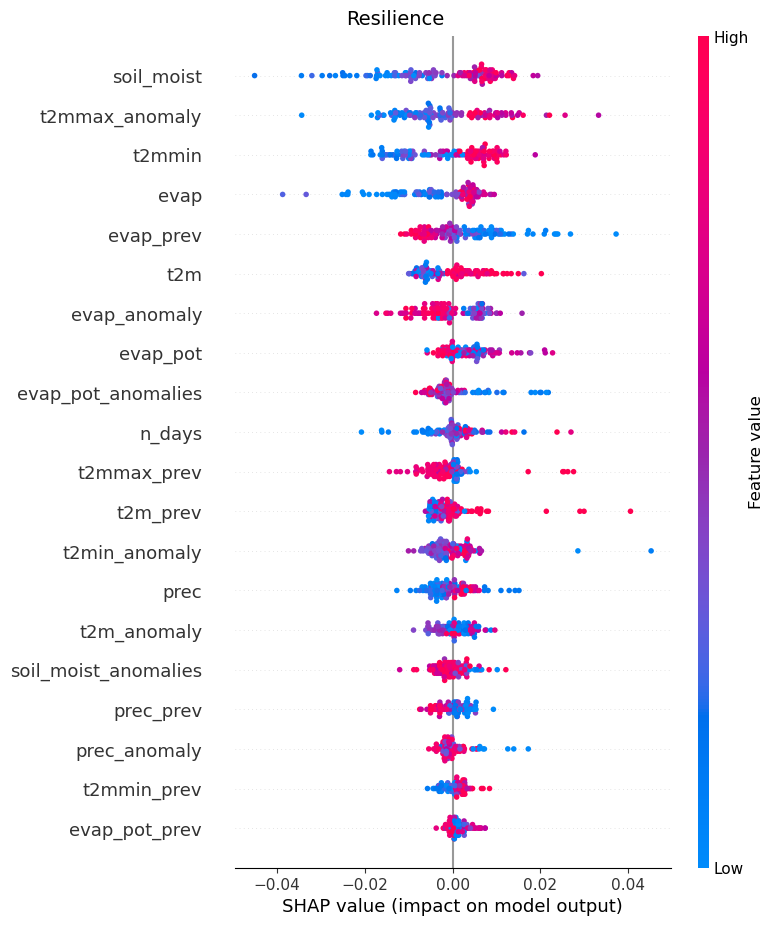

In [306]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_resl, X_test_resl, show=False)
plt.suptitle("Resilience", fontsize=14, y=0.97)
plt.tight_layout()
plt.show()

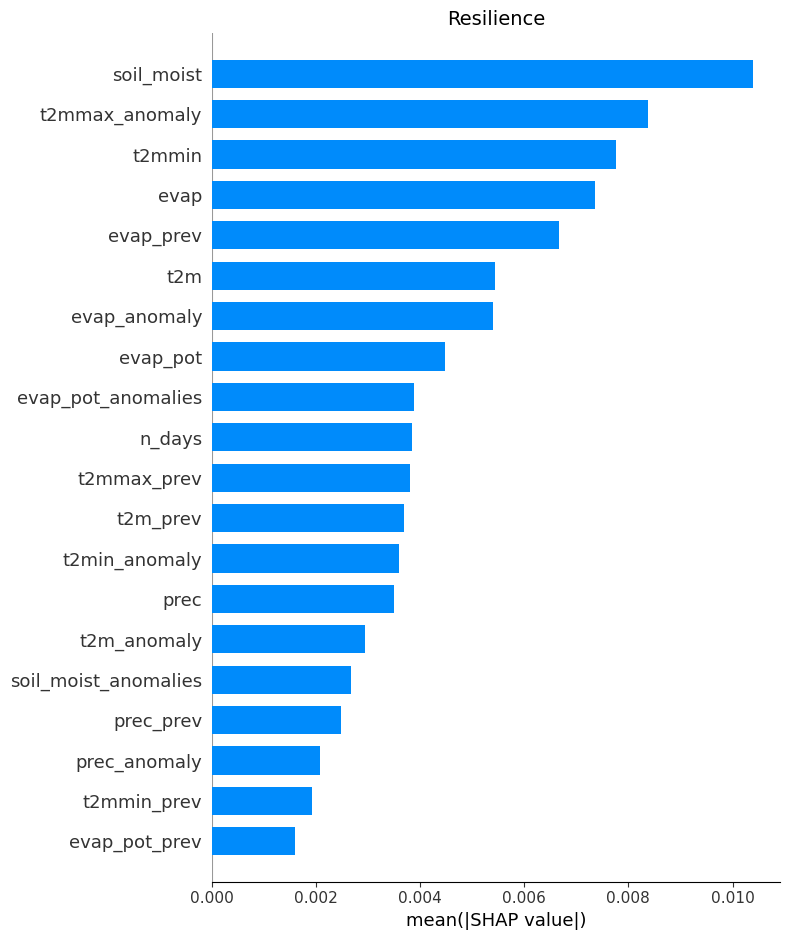

In [286]:
shap.summary_plot(shap_values_resl, X_test_resl, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resilience", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()

Mean absolute SHAP value for 'soil_moist': 0.0104
Mean absolute SHAP value for 't2mmax_anomaly': 0.0084


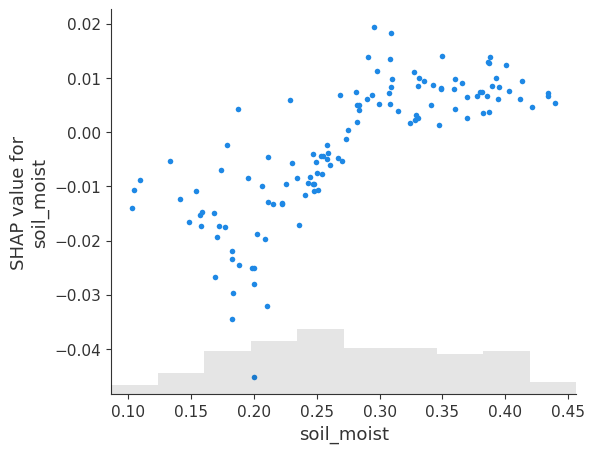

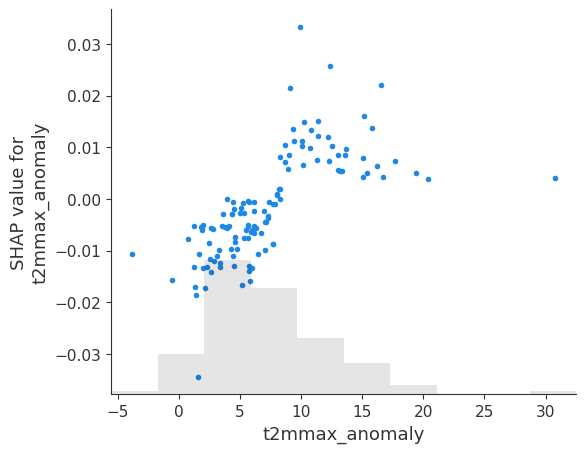

In [363]:
variable1 = 'soil_moist'
variable2 = 't2mmax_anomaly'

# Create dataframe with sha values
shap_values_df = pd.DataFrame(shap_values_resl.values, columns=X_test_resl.columns)

# Compute the mean absolute SHAP value for the chosen variable
mean_abs_shap1 = np.mean(np.abs(shap_values_df[variable1]))
mean_abs_shap2 = np.mean(np.abs(shap_values_df[variable2]))

print(f"Mean absolute SHAP value for '{variable1}': {mean_abs_shap1:.4f}")
print(f"Mean absolute SHAP value for '{variable2}': {mean_abs_shap2:.4f}")

shap.plots.scatter(shap_values_resl[:, variable1])
shap.plots.scatter(shap_values_resl[:, variable2])


#### Resistance

In [288]:
explainer_rest = shap.Explainer(xgb_rest)
shap_values_rest = explainer_rest(X_test_rest)

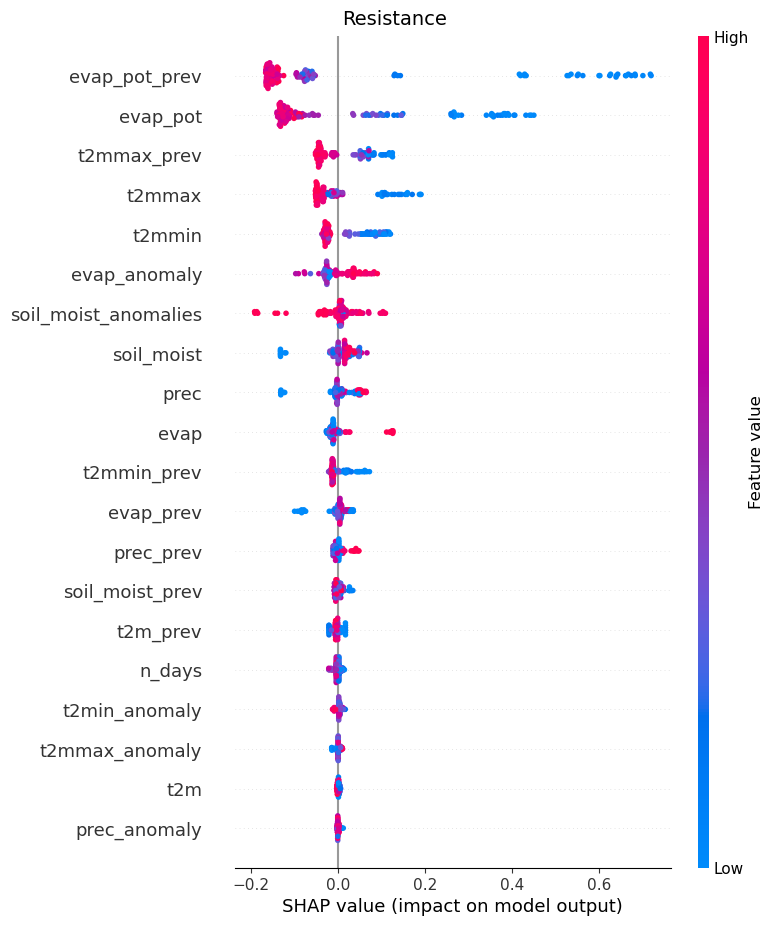

In [308]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rest, X_test_rest, show=False)
plt.suptitle("Resistance", fontsize=14, y=0.97)
plt.tight_layout()
plt.show()

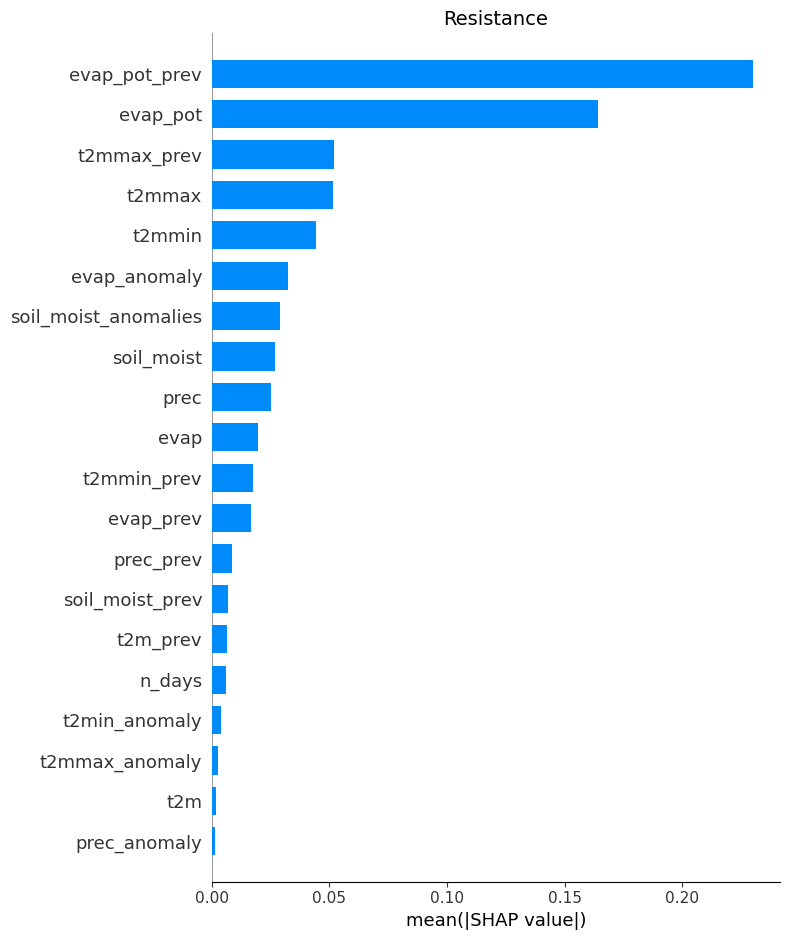

In [290]:
# Create SHAP summary plot
shap.summary_plot(shap_values_rest, X_test_rest, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Resistance", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()


Mean absolute SHAP value for 'evap_pot_prev': 0.2300
Mean absolute SHAP value for 'evap_pot': 0.1639


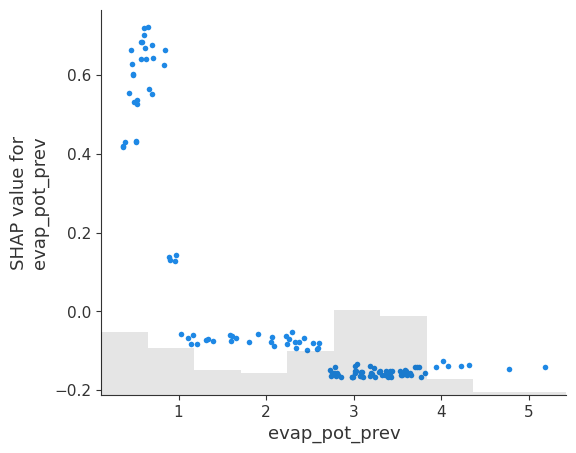

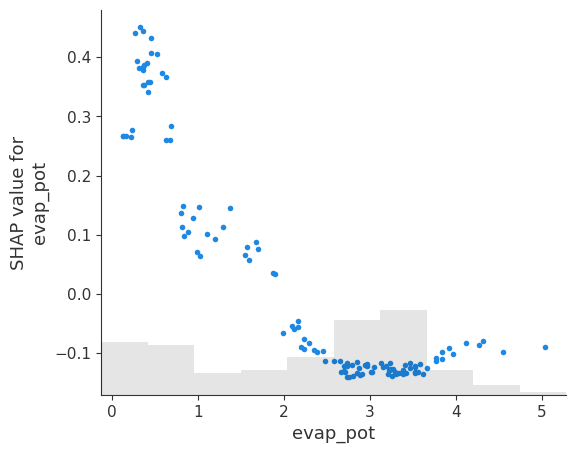

In [362]:
variable1 = 'evap_pot_prev'
variable2 = 'evap_pot'

# Create dataframe with sha values
shap_values_df = pd.DataFrame(shap_values_rest.values, columns=X_test_rest.columns)

# Compute the mean absolute SHAP value for the chosen variable
mean_abs_shap1 = np.mean(np.abs(shap_values_df[variable1]))
mean_abs_shap2 = np.mean(np.abs(shap_values_df[variable2]))

print(f"Mean absolute SHAP value for '{variable1}': {mean_abs_shap1:.4f}")
print(f"Mean absolute SHAP value for '{variable2}': {mean_abs_shap2:.4f}")

shap.plots.scatter(shap_values_rest[:, variable1])
shap.plots.scatter(shap_values_rest[:, variable2])



#### Recovery

In [292]:
explainer_rec = shap.Explainer(xgb_rec)
shap_values_rec = explainer_rec(X_test_rec)

In [365]:
shap_values_rec.shape

(123, 22)

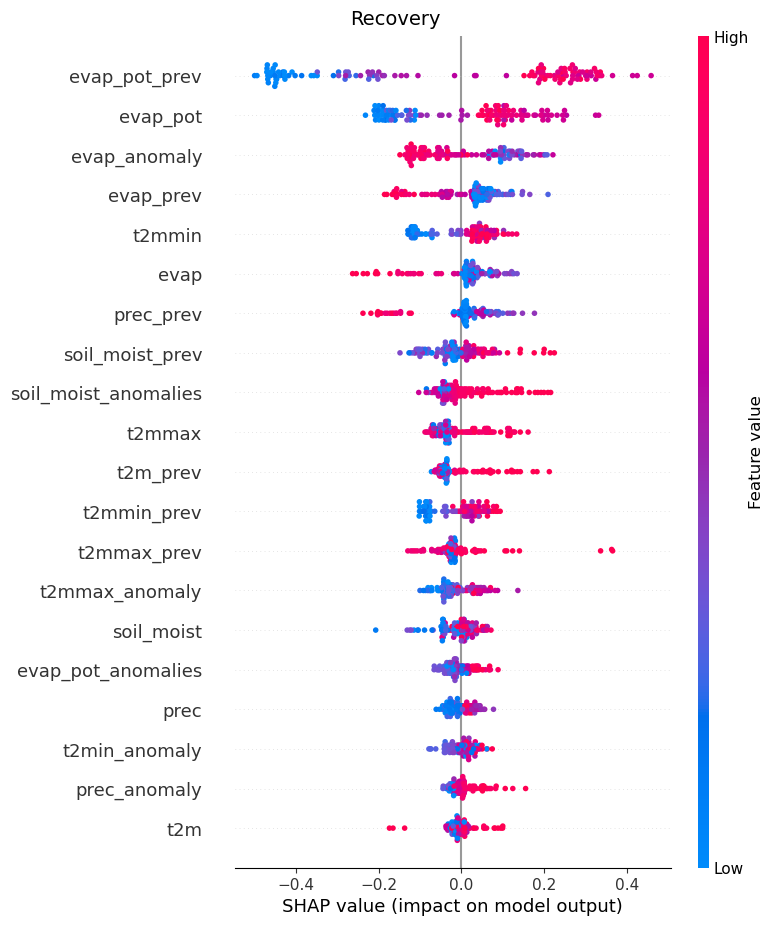

In [310]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rec, X_test_rec, show=False)
plt.suptitle("Recovery", fontsize=14, y=0.97)
plt.tight_layout()
plt.show()

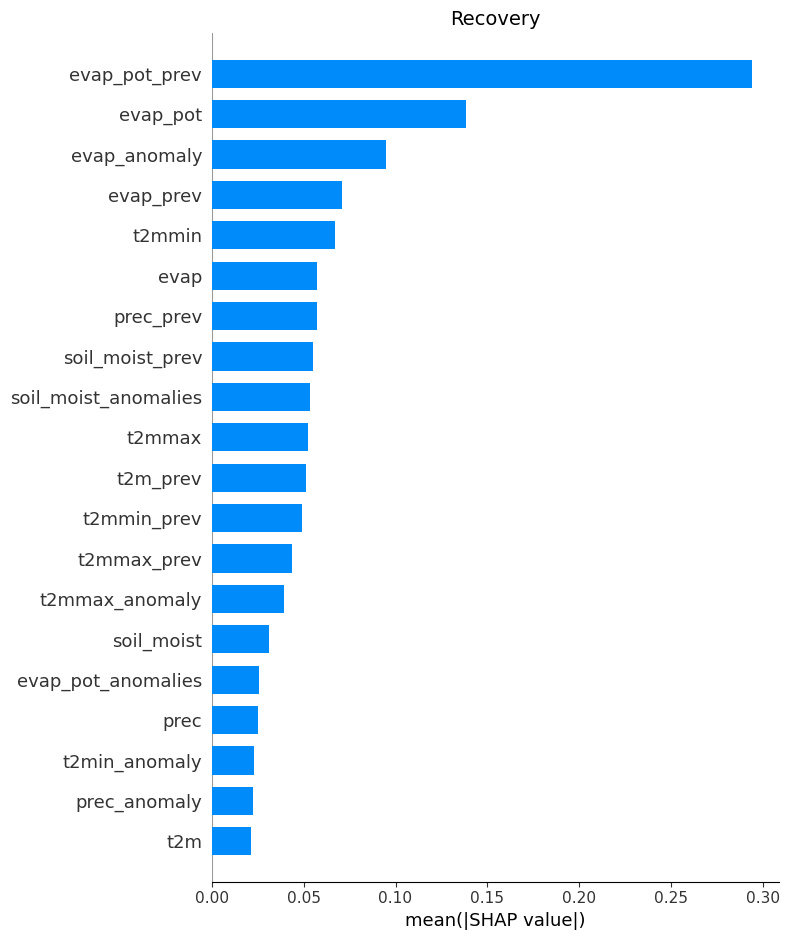

In [311]:
shap.summary_plot(shap_values_rec, X_test_rec, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("Recovery", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()

Mean absolute SHAP value for 'evap_pot_prev': 0.2941
Mean absolute SHAP value for 'evap_pot': 0.1384


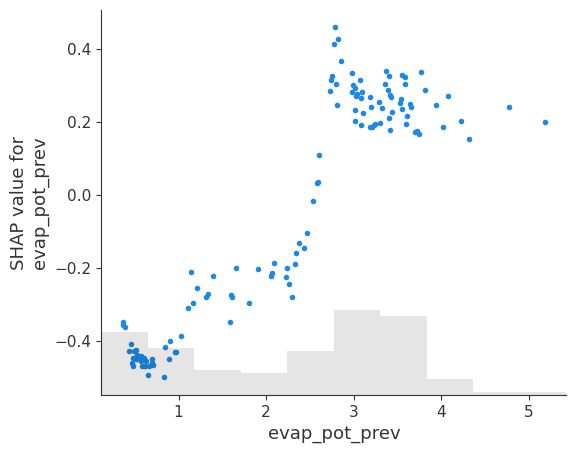

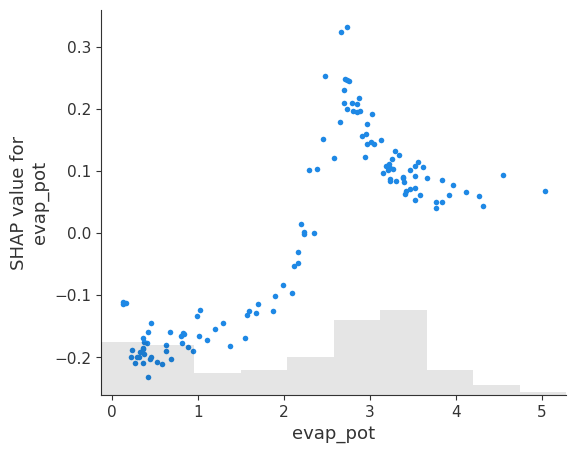

In [361]:
variable1 = 'evap_pot_prev'
variable2 = 'evap_pot'

# Create dataframe with sha values
shap_values_df = pd.DataFrame(shap_values_rec.values, columns=X_test_rec.columns)

# Compute the mean absolute SHAP value for the chosen variable
mean_abs_shap1 = np.mean(np.abs(shap_values_df[variable1]))
mean_abs_shap2 = np.mean(np.abs(shap_values_df[variable2]))

print(f"Mean absolute SHAP value for '{variable1}': {mean_abs_shap1:.4f}")
print(f"Mean absolute SHAP value for '{variable2}': {mean_abs_shap2:.4f}")

shap.plots.scatter(shap_values_rec[:, variable1])
shap.plots.scatter(shap_values_rec[:, variable2])


#### Anomaly

In [296]:
explainer_anom = shap.Explainer(xgb_anom)
shap_values_anom = explainer_anom(X_test_anom)

Global overview of feature impact per observation:

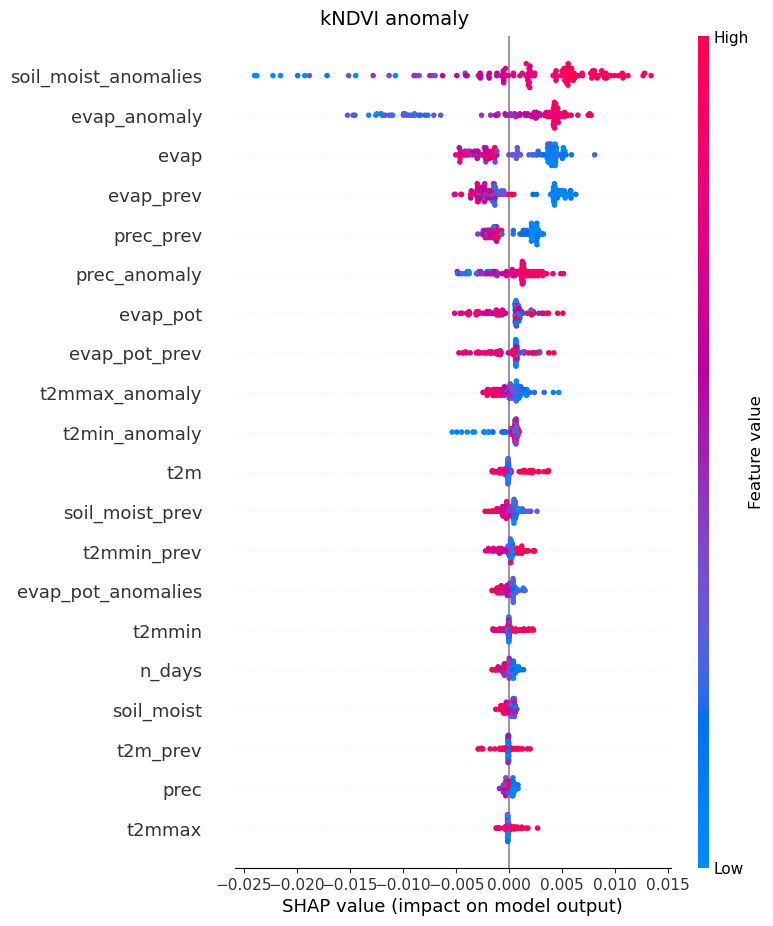

In [312]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_anom, X_test_anom, show=False)
plt.suptitle("kNDVI anomaly", fontsize=14, y=0.97)
plt.tight_layout()
plt.show()

Average feature impact across dataset:

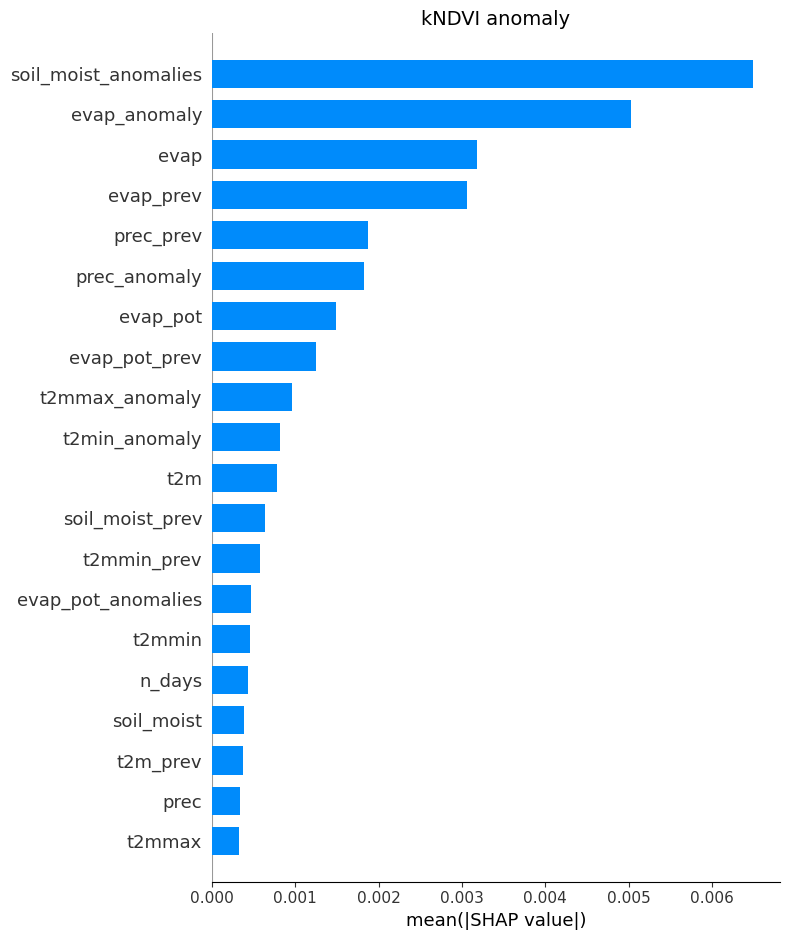

In [313]:
shap.summary_plot(shap_values_anom, X_test_anom, plot_type="bar", show=False)

# Get current axis and add a title
plt.title("kNDVI anomaly", fontsize=14)
plt.xlabel('mean(|SHAP value|)')

# Adjust layout and display
plt.tight_layout()
plt.show()

Dependence plot of most important feature:

Mean absolute SHAP value for 'soil_moist_anomalies': 0.0065
Mean absolute SHAP value for 'evap_anomaly': 0.0050


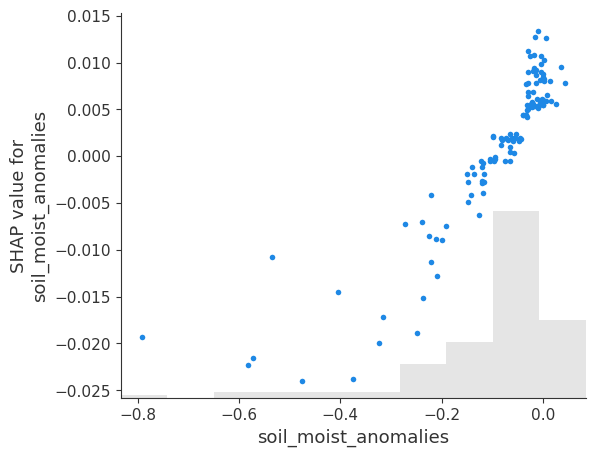

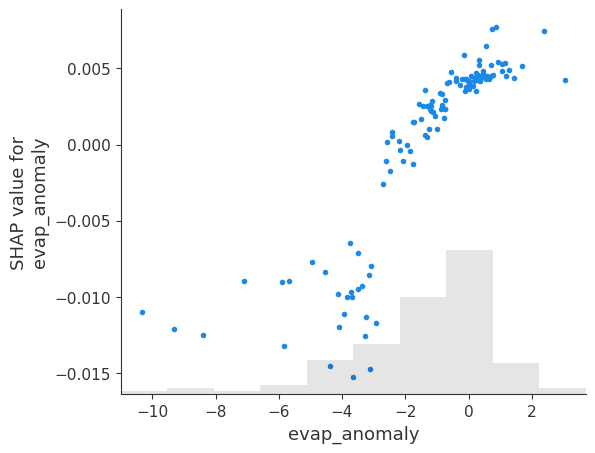

In [360]:
variable1 = 'soil_moist_anomalies'
variable2 = 'evap_anomaly'

# Create dataframe with sha values
shap_values_df = pd.DataFrame(shap_values_anom.values, columns=X_test_anom.columns)

# Compute the mean absolute SHAP value for the chosen variable
mean_abs_shap1 = np.mean(np.abs(shap_values_df[variable1]))
mean_abs_shap2 = np.mean(np.abs(shap_values_df[variable2]))

print(f"Mean absolute SHAP value for '{variable1}': {mean_abs_shap1:.4f}")
print(f"Mean absolute SHAP value for '{variable2}': {mean_abs_shap2:.4f}")

shap.plots.scatter(shap_values_anom[:, variable1])
shap.plots.scatter(shap_values_anom[:, variable2])
